# SmartCart - Notebook 6: Model Comparison, Hybrid Reranking, and Rule Extensions

This notebook extends the existing methodology with controlled improvements:
- Baseline comparison (Popularity, Item-CF, User-CF)
- Hybrid reranking (User-CF + category preference)
- Segment-aware and stability-aware association rule analysis

## Inputs
- `data/processed/user_data_clean.csv`
- `data/processed/product_data_clean.csv`
- `data/processed/user_item_matrix_filled.csv`
- `data/processed/user_category_agg.csv`

Run Notebook 1 first. This notebook keeps the same core methodology and only adds comparative analysis.

In [1]:
from pathlib import Path
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

In [2]:
cwd = Path.cwd()
processed_candidates = [cwd / 'data' / 'processed', cwd.parent / 'data' / 'processed']
processed_dir = next((p for p in processed_candidates if p.exists()), processed_candidates[0])

required_files = [
    'user_data_clean.csv',
    'product_data_clean.csv',
    'user_item_matrix_filled.csv',
    'user_category_agg.csv',
]
missing = [f for f in required_files if not (processed_dir / f).exists()]
if missing:
    raise FileNotFoundError('Missing processed files: ' + ', '.join(missing))

user_data = pd.read_csv(processed_dir / 'user_data_clean.csv', parse_dates=['Timestamp'])
product_data = pd.read_csv(processed_dir / 'product_data_clean.csv')
user_item_matrix_filled = pd.read_csv(processed_dir / 'user_item_matrix_filled.csv', index_col=0).astype(np.float64)
user_category_agg = pd.read_csv(processed_dir / 'user_category_agg.csv', parse_dates=['LastInteraction'])

print('Loaded from:', processed_dir)
print('user_item_matrix shape:', user_item_matrix_filled.shape)

Loaded from: /Users/solaris003/Repository/Projects/Recommender System & Pattern Mining for E-Commerce Analytics/data/processed
user_item_matrix shape: (50, 100)


In [3]:
def safe_cosine_similarity(matrix_like):
    matrix = np.asarray(matrix_like, dtype=np.float64)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            return cosine_similarity(matrix)

def average_precision_at_k(recommended_items, relevant_items, k):
    if not relevant_items:
        return 0.0
    hits = 0
    score = 0.0
    for rank, item in enumerate(recommended_items[:k], start=1):
        if item in relevant_items:
            hits += 1
            score += hits / rank
    return score / min(len(relevant_items), k)

def list_diversity(rec_list, item_sim_df):
    if len(rec_list) < 2:
        return np.nan
    distances = [1 - item_sim_df.loc[a, b] for a, b in combinations(rec_list, 2)]
    return float(np.mean(distances)) if distances else np.nan

## A) Baseline and Model Comparison

In [4]:
K = 5
rng = np.random.default_rng(42)

ratings = user_item_matrix_filled.copy()
interaction_mask = ratings > 0
eligible_users = interaction_mask.sum(axis=1) >= 2

train = ratings.copy()
test_items_by_user = {}
for user in train.index[eligible_users]:
    seen_items = train.columns[train.loc[user] > 0]
    held_out = rng.choice(seen_items.to_numpy())
    test_items_by_user[user] = {held_out}
    train.loc[user, held_out] = 0.0

user_sim = pd.DataFrame(safe_cosine_similarity(train), index=train.index, columns=train.index)
item_sim = pd.DataFrame(safe_cosine_similarity(train.T), index=train.columns, columns=train.columns)

global_popularity = (train > 0).sum(axis=0).sort_values(ascending=False)

In [5]:
product_category_map = product_data.drop_duplicates('ProductID').set_index('ProductID')['Category'].to_dict()
user_cat_pref = (
    user_data.groupby(['UserID', 'Category']).size().rename('cnt').reset_index()
    .assign(total=lambda d: d.groupby('UserID')['cnt'].transform('sum'))
    .assign(pref=lambda d: d['cnt'] / d['total'])
)
user_cat_pref_map = {(r['UserID'], r['Category']): r['pref'] for _, r in user_cat_pref.iterrows()}

def cf_scores_user(user, ratings_matrix, user_similarity_df, neighbor_top_m=10):
    if user not in ratings_matrix.index:
        return pd.Series(dtype=float)
    neighbors = user_similarity_df.loc[user].drop(index=user, errors='ignore').sort_values(ascending=False).head(neighbor_top_m)
    neighbors = neighbors[neighbors > 0]
    if neighbors.empty:
        return pd.Series(dtype=float)
    target = ratings_matrix.loc[user]
    unrated = target[target <= 0].index
    if len(unrated) == 0:
        return pd.Series(dtype=float)
    neighbor_ratings = ratings_matrix.loc[neighbors.index, unrated]
    weighted = neighbor_ratings.T.dot(neighbors.values)
    denom = np.abs(neighbors.values).sum()
    if denom == 0:
        return pd.Series(dtype=float)
    return (weighted / denom).sort_values(ascending=False)

def recommend_popularity(user, ratings_matrix, top_k=5):
    seen = set(ratings_matrix.columns[ratings_matrix.loc[user] > 0])
    recs = [i for i in global_popularity.index if i not in seen]
    return recs[:top_k]

def recommend_item_cf(user, ratings_matrix, item_similarity_df, top_k=5):
    user_r = ratings_matrix.loc[user]
    rated = user_r[user_r > 0]
    unrated = user_r[user_r <= 0].index
    if rated.empty:
        return []
    sims = item_similarity_df.loc[unrated, rated.index]
    weighted = sims.dot(rated.values)
    denom = np.abs(sims).sum(axis=1).replace(0, np.nan)
    scores = (weighted / denom).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
    return scores.head(top_k).index.tolist()

def recommend_user_cf(user, ratings_matrix, user_similarity_df, top_k=5):
    scores = cf_scores_user(user, ratings_matrix, user_similarity_df)
    return scores.head(top_k).index.tolist()

def recommend_hybrid(user, ratings_matrix, user_similarity_df, alpha=0.7, top_k=5):
    cf = cf_scores_user(user, ratings_matrix, user_similarity_df)
    if cf.empty:
        return []
    cf_norm = (cf - cf.min()) / (cf.max() - cf.min() + 1e-12)

    content_scores = {}
    for item in cf_norm.index:
        cat = product_category_map.get(item)
        content_scores[item] = user_cat_pref_map.get((user, cat), 0.0)
    content = pd.Series(content_scores)

    if content.max() > content.min():
        content_norm = (content - content.min()) / (content.max() - content.min() + 1e-12)
    else:
        content_norm = content

    hybrid = alpha * cf_norm + (1 - alpha) * content_norm
    return hybrid.sort_values(ascending=False).head(top_k).index.tolist()

In [6]:
def evaluate_model(recommend_fn, model_name):
    precision_scores, recall_scores, ap_scores = [], [], []
    all_recs = set()
    diversity_scores = []
    users_eval = 0

    for user, relevant in test_items_by_user.items():
        recs = recommend_fn(user)
        if not recs:
            continue
        users_eval += 1
        hits = len(set(recs) & relevant)
        precision_scores.append(hits / K)
        recall_scores.append(hits / len(relevant))
        ap_scores.append(average_precision_at_k(recs, relevant, K))
        all_recs.update(recs)
        diversity_scores.append(list_diversity(recs, item_sim))

    coverage = len(all_recs) / train.shape[1] if train.shape[1] > 0 else 0.0
    mean_div = np.nanmean(diversity_scores) if diversity_scores else np.nan

    return {
        'Model': model_name,
        'UsersEvaluated': users_eval,
        'Precision@K': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'Recall@K': float(np.mean(recall_scores)) if recall_scores else 0.0,
        'MAP@K': float(np.mean(ap_scores)) if ap_scores else 0.0,
        'Coverage': float(coverage),
        'Diversity': float(mean_div) if not np.isnan(mean_div) else np.nan,
    }

results = []
results.append(evaluate_model(lambda u: recommend_popularity(u, train, K), 'Popularity Baseline'))
results.append(evaluate_model(lambda u: recommend_item_cf(u, train, item_sim, K), 'Item-Based CF'))
results.append(evaluate_model(lambda u: recommend_user_cf(u, train, user_sim, K), 'User-Based CF'))
results.append(evaluate_model(lambda u: recommend_hybrid(u, train, user_sim, alpha=0.7, top_k=K), 'Hybrid (User-CF + Content)'))

comparison_df = pd.DataFrame(results).sort_values('MAP@K', ascending=False).reset_index(drop=True)
comparison_df

,Model,UsersEvaluated,Precision@K,Recall@K,MAP@K,Coverage,Diversity
0,Hybrid (User-CF + Content),50,0.044,0.22,0.145667,0.71,0.818396
1,User-Based CF,50,0.036,0.18,0.109000,0.76,0.804878
2,Popularity Baseline,50,0.016,0.08,0.048000,0.10,0.815457
3,Item-Based CF,50,0.012,0.06,0.016667,0.80,0.838859


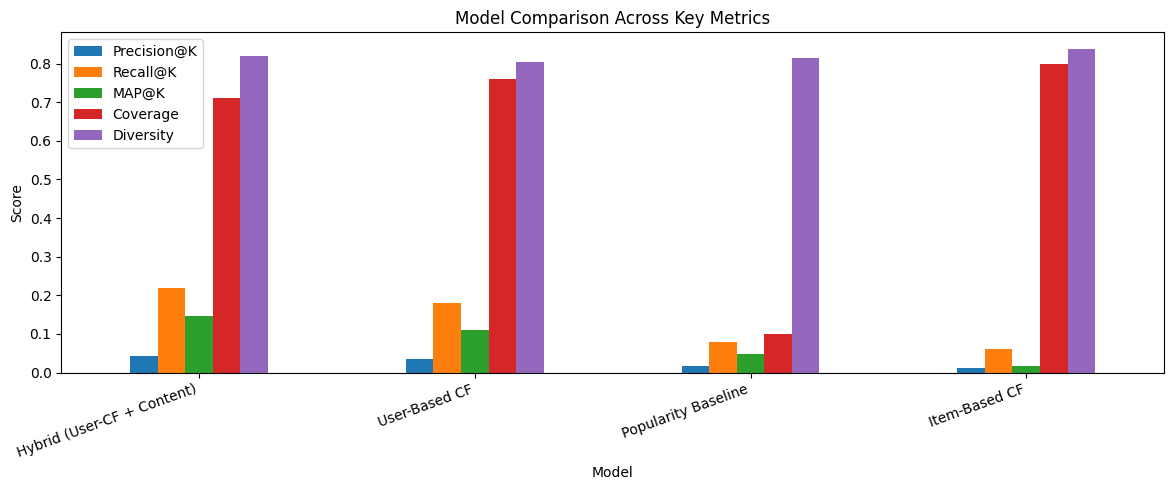

In [7]:
plot_metrics = ['Precision@K', 'Recall@K', 'MAP@K', 'Coverage', 'Diversity']
ax = comparison_df.set_index('Model')[plot_metrics].plot(kind='bar', figsize=(12, 5))
ax.set_title('Model Comparison Across Key Metrics')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## B) Association Rules: Segment and Stability Extensions

In [8]:
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
except Exception as e:
    print('mlxtend unavailable. Using fallback simple pair mining:', type(e).__name__)
    TransactionEncoder = None
    apriori = None
    association_rules = None

def build_transactions(df):
    return (
        df.groupby('UserID')['ProductID']
        .apply(lambda s: sorted(set(s.astype(str))))
        .tolist()
    )

def mine_rules_mlxtend(transactions, min_support=0.08, min_conf=0.35, max_len=3):
    te = TransactionEncoder()
    tx_matrix = te.fit(transactions).transform(transactions)
    tx_df = pd.DataFrame(tx_matrix, columns=te.columns_)
    fi = apriori(tx_df, min_support=min_support, use_colnames=True, max_len=max_len)
    if fi.empty:
        return pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
    rules = association_rules(fi, metric='confidence', min_threshold=min_conf)
    if rules.empty:
        return pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
    return rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)

def mine_pair_rules_fallback(transactions, min_support=0.08, min_conf=0.35):
    tx_sets = [set(t) for t in transactions if len(t) > 0]
    n = len(tx_sets)
    if n == 0:
        return pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])

    item_count = {}
    pair_count = {}
    for tx in tx_sets:
        for i in tx:
            item_count[i] = item_count.get(i, 0) + 1
        for a, b in combinations(sorted(tx), 2):
            pair_count[(a, b)] = pair_count.get((a, b), 0) + 1

    rows = []
    for (a, b), c_ab in pair_count.items():
        sup_ab = c_ab / n
        if sup_ab < min_support:
            continue
        sup_a = item_count[a] / n
        sup_b = item_count[b] / n

        conf_a_b = sup_ab / sup_a if sup_a else 0.0
        lift_a_b = conf_a_b / sup_b if sup_b else 0.0
        if conf_a_b >= min_conf:
            rows.append({'antecedents': frozenset([a]), 'consequents': frozenset([b]), 'support': sup_ab, 'confidence': conf_a_b, 'lift': lift_a_b})

        conf_b_a = sup_ab / sup_b if sup_b else 0.0
        lift_b_a = conf_b_a / sup_a if sup_a else 0.0
        if conf_b_a >= min_conf:
            rows.append({'antecedents': frozenset([b]), 'consequents': frozenset([a]), 'support': sup_ab, 'confidence': conf_b_a, 'lift': lift_b_a})

    if not rows:
        return pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
    return pd.DataFrame(rows).sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)

def mine_rules(transactions, min_support=0.08, min_conf=0.35, max_len=3):
    if apriori is not None and association_rules is not None and TransactionEncoder is not None:
        return mine_rules_mlxtend(transactions, min_support=min_support, min_conf=min_conf, max_len=max_len)
    return mine_pair_rules_fallback(transactions, min_support=min_support, min_conf=min_conf)

In [9]:
transactions_all = build_transactions(user_data)
rules_all = mine_rules(transactions_all, min_support=0.08, min_conf=0.35, max_len=3)

bundle_shortlist = rules_all[(rules_all['support'] >= 0.08) & (rules_all['confidence'] >= 0.35) & (rules_all['lift'] > 1.1)].copy()
bundle_shortlist = bundle_shortlist.head(15)

print('Global rules:', len(rules_all))
bundle_shortlist

Global rules: 154


,antecedents,consequents,support,confidence,lift
0,"(P0022, P0070)",(P0015),0.08,1.000000,6.250000
1,"(P0039, P0070)",(P0015),0.08,1.000000,6.250000
2,(P0015),"(P0022, P0070)",0.08,0.500000,6.250000
3,(P0015),"(P0039, P0070)",0.08,0.500000,6.250000
4,"(P0079, P0044)",(P0013),0.08,0.800000,5.714286
5,"(P0015, P0070)",(P0022),0.08,0.800000,5.714286
6,"(P0015, P0070)",(P0039),0.08,0.800000,5.714286
7,(P0013),"(P0079, P0044)",0.08,0.571429,5.714286
8,(P0022),"(P0015, P0070)",0.08,0.571429,5.714286
9,(P0039),"(P0015, P0070)",0.08,0.571429,5.714286


In [10]:
user_primary_group = (
    user_category_agg.sort_values(['UserID', 'TotalInteractions'], ascending=[True, False])
    .drop_duplicates(subset='UserID')
    [['UserID', 'Category']]
    .rename(columns={'Category': 'UserGroup'})
)

user_group_data = user_data[['UserID', 'ProductID', 'Timestamp']].merge(user_primary_group, on='UserID', how='left')

segment_rows = []
for group_name, gdf in user_group_data.groupby('UserGroup'):
    tx = build_transactions(gdf[['UserID', 'ProductID']])
    if len(tx) < 10:
        continue
    rules_seg = mine_rules(tx, min_support=0.10, min_conf=0.35, max_len=3)
    top = rules_seg.head(5).copy()
    if top.empty:
        continue
    top['UserGroup'] = group_name
    segment_rows.append(top)

segment_rules = pd.concat(segment_rows, ignore_index=True) if segment_rows else pd.DataFrame()
segment_rules

,antecedents,consequents,support,confidence,lift,UserGroup
0,(P0003),(P0009),0.100000,1.0,10.0,Beauty
1,(P0009),(P0003),0.100000,1.0,10.0,Beauty
2,(P0042),(P0003),0.100000,1.0,10.0,Beauty
3,(P0003),(P0042),0.100000,1.0,10.0,Beauty
4,(P0051),(P0003),0.100000,1.0,10.0,Beauty
5,(P0043),(P0019),0.111111,1.0,9.0,Books
6,(P0019),(P0043),0.111111,1.0,9.0,Books
7,"(P0005, P0003)",(P0047),0.111111,1.0,9.0,Books
8,(P0047),"(P0005, P0003)",0.111111,1.0,9.0,Books
9,"(P0033, P0003)",(P0047),0.111111,1.0,9.0,Books


In [11]:
# Rule stability check across months for shortlist itemsets
if not bundle_shortlist.empty:
    data_m = user_data.copy()
    data_m['YearMonth'] = data_m['Timestamp'].dt.to_period('M').astype(str)

    # Build month-level transactions as sets
    month_tx = {
        m: [set(t) for t in build_transactions(g[['UserID', 'ProductID']])]
        for m, g in data_m.groupby('YearMonth')
    }

    stability_rows = []
    for _, row in bundle_shortlist.head(10).iterrows():
        itemset = set(row['antecedents']) | set(row['consequents'])
        month_supports = []
        for m, tx_list in month_tx.items():
            if len(tx_list) == 0:
                continue
            sup = sum(1 for tx in tx_list if itemset.issubset(tx)) / len(tx_list)
            month_supports.append((m, sup))

        if month_supports:
            supports = [s for _, s in month_supports]
            stability_rows.append({
                'Rule': f"{set(row['antecedents'])} -> {set(row['consequents'])}",
                'AvgMonthlySupport': float(np.mean(supports)),
                'StdMonthlySupport': float(np.std(supports)),
                'MonthsObserved': len(supports),
            })

    stability_df = pd.DataFrame(stability_rows).sort_values('AvgMonthlySupport', ascending=False)
else:
    stability_df = pd.DataFrame(columns=['Rule', 'AvgMonthlySupport', 'StdMonthlySupport', 'MonthsObserved'])

stability_df.head(10)

,Rule,AvgMonthlySupport,StdMonthlySupport,MonthsObserved
1,"{'P0039', 'P0070'} -> {'P0015'}",0.03,0.01,2
3,"{'P0015'} -> {'P0039', 'P0070'}",0.03,0.01,2
6,"{'P0015', 'P0070'} -> {'P0039'}",0.03,0.01,2
9,"{'P0039'} -> {'P0015', 'P0070'}",0.03,0.01,2
4,"{'P0079', 'P0044'} -> {'P0013'}",0.02,0.00,2
7,"{'P0013'} -> {'P0079', 'P0044'}",0.02,0.00,2
0,"{'P0022', 'P0070'} -> {'P0015'}",0.01,0.01,2
2,"{'P0015'} -> {'P0022', 'P0070'}",0.01,0.01,2
5,"{'P0015', 'P0070'} -> {'P0022'}",0.01,0.01,2
8,"{'P0022'} -> {'P0015', 'P0070'}",0.01,0.01,2


## Results
### 1. Model Comparison Outcomes
The evaluation was conducted on **50 users** across four recommendation strategies.

- **Hybrid (User-CF + Content)** achieved the best relevance performance:
  - Precision@K: **0.044**
  - Recall@K: **0.22**
  - MAP@K: **0.145667**
  - Coverage: **0.71**
  - Diversity: **0.818396**

- **User-Based CF** was second-best on relevance:
  - Precision@K: **0.036**
  - Recall@K: **0.18**
  - MAP@K: **0.109000**
  - Coverage: **0.76**
  - Diversity: **0.804878**

- **Popularity Baseline** and **Item-Based CF** underperformed on relevance:
  - Popularity Baseline MAP@K: **0.048000**
  - Item-Based CF MAP@K: **0.016667**

Interpretation: adding category-aware content signals to User-CF improved ranking quality while keeping diversity and coverage at practical levels.

### 2. Global Association Rule Mining
- Total global rules discovered: **154**
- Top rules show strong association strength with:
  - Support around **0.08 to 0.10**
  - Confidence up to **1.00**
  - Lift up to **6.25**

Interpretation: these rules indicate meaningful co-occurrence patterns suitable for bundle and cross-sell recommendations.

### 3. Segment-Aware Rule Findings
Segment-level mining revealed stronger and more specialized patterns than global-only rules:

- **Beauty** segment: lift up to **10.0**, confidence **1.0**
- **Books** segment: lift up to **9.0**, confidence **1.0**
- **Electronics** segment: lift up to **6.5**, confidence **1.0**

Interpretation: recommendation and promotion logic should be adapted by segment rather than relying on one universal rule set.

### 4. Rule Stability Across Time
For shortlisted rules tracked across months:
- AvgMonthlySupport ranged approximately **0.01 to 0.03**
- StdMonthlySupport remained low (**0.00 to 0.01**)
- MonthsObserved: **2**

Interpretation: the strongest rules are relatively stable in the observed period, but longer monitoring windows are recommended before production deployment.

The expanded pipeline improves analytical rigor without changing the core project methodology. The **hybrid recommender is the best-performing model**, and the **association rule module provides actionable, segment-specific bundle intelligence** with initial temporal stability evidence.